In [1]:
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.transforms import Compose, ToTensor, Normalize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib为黑色主题
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': 'black',
    'axes.facecolor': 'black',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#444444',
    'grid.alpha': 0.3,
    'legend.facecolor': 'black',
    'legend.edgecolor': 'white',
})

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)


# <font color="#00FFFF" >**第四章 卷积神经网络基础与入门实践**</font>

## 本章内容

> 1. **卷积神经网络简介**
>    - 从生物视觉到CNN
>    - 卷积运算与互相关运算
>    - 卷积的三种形式（Valid、Same、Full）
>    - 感受野与池化操作
>
> 2. **图像表示与通道概念**
>    - 像素与像素值
>    - RGB与灰度图像
>    - 数据格式（NCHW vs NHWC）
>    - 归一化处理
>
> 3. **典型的卷积神经网络架构**
>    - 典型卷积块（Convolutional Block）
>    - LeNet-5与AlexNet
>    - 自适应池化（Adaptive Pooling）
>
> 4. **网络配置与损失函数应匹配**
>    - 网络架构与损失函数匹配表
>    - 类别不平衡问题与weight/pos_weight
>
> 5. **PyTorch实现CNN图像分类（完整流程）**
>    - 数据生成与分割
>    - 自定义Dataset与DataLoader
>    - WeightedRandomSampler处理类别不平衡
>    - 模型定义与训练流程
>    - 模型性能评估

##  <font color="#FFEA00" >**第1节 卷积神经网络简介**</font>

### **<font color="#39FF14" >一、从生物视觉到卷积神经网络</font>**

### <font color="#CCFF00">**为什么需要卷积神经网络？**</font>

##### <font color="#00ffbf">**如果使用MLP处理图像数据，会怎么样？**</font>


在MLP中，我们把图像数据展开成一维向量，丢失了空间信息

<font color="#FF00A0" >**问题**</font>：
1. **丢失空间结构**：相邻像素之间的关系被破坏
2. **参数量巨大**：全连接层参数量 = 输入维度 × 输出维度
3. **无法利用平移不变性**：同一特征在不同位置需要分别学习


#### <font color="#CCFF00">**Hubel & Wiesel的发现（1962年，1981年诺贝尔奖）**</font>

神经科学领域的突破性研究“关于视觉系统的信息处理的发现”：证明了大脑不是 “被动的视网膜投影”，而是主动的特征提取系统，彻底推翻了当时 “视觉是视网膜图像直接投射到皮层” 的错误理论，为卷积神经网络奠定了生物学基础。

| 细胞类型 | 功能 | 对应CNN组件 |
|:--------:|:----:|:-----------:|
| **简单细胞（Simple cells）** | 检测局部特征（如边缘） | 卷积核/滤波器 |
| **复杂细胞（Complex cells）** | 组合相邻简单细胞的输出，具有平移不变性 | 池化层 |


<font color="#FF00A0" >**CNN核心特点**</font>：
- **局部连接**：每个神经元（输出特征图上的一个像素点）只连接局部区域
- **权值共享**：同一卷积核在整个图像上滑动
- **平移不变性**：池化操作提供局域位置不变性

### **<font color="#39FF14" size=6 >什么是卷积神经网络？</font>**

#### <font color="#CCFF00">**从全连接到局部连接**</font>

**卷积神经网络**（Convolutional Neural Network, **CNN**）是一种专门处理**具有网格结构数据**的神经网络，最擅长处理图像（2D网格）。

与MLP的**全连接**不同，CNN采用**局部连接**的思想

💡 **核心思想**：用**卷积核Kernel/Filter**在图像上滑动，提取局部特征，逐步构建从简单到复杂的特征层次。


### **<font color="#39FF14" size=6 >什么是卷积操作？</font>**

#### <font color="#CCFF00">**卷积**</font>


<font color="#FF00A0" >**卷积操作**</font>：
1. **看**：聚焦图像的某一小块区域（如3×3像素）
2. **算**：将这9个像素与卷积核的9个权重**对应相乘再求和**
3. **记**：把结果写入新图像的对应位置
4. **移**：滑动到下一个位置，重复上述过程


卷积后的特征图大小取决于滤波器的大小，滤波器越大，生成的图像越小。
卷积核越大，特征图越小

$$\left(h_{i}, w_{i}\right) * f=\left(h_{i}-f+1, w_{i}-f+1\right)$$

把核从头往右走，顶住之后再加一，公式来源（这个情况是默认步数为1的情况下的）

💡 **类比**：卷积就像给图像加**滤镜**——边缘检测滤镜让边缘突出，模糊滤镜让图像平滑，锐化滤镜让细节清晰。

##### <font color="#CCFF00" > **步长** </font>

使用步长参数$s$，更新特征图尺寸计算公式：

$$\left(h_{i}, w_{i}\right) * f=\left(\frac{h_{i}-f+1}{s}, \frac{w_{i}-f+1}{s}\right)$$

平时步数默认一步

##### <font color="#CCFF00" > **填充** </font>

外围填充一圈去保证处理完尺寸仍然和输入一致

填充模式：常数填充、反射填充、复制填充、循环填充

通常采用的策略

| 场景 | 推荐策略 | 原因 |
|------|----------|------|
| 通用图像分类 | 零填充 | 简单高效，主流框架默认 |
| 语义分割 | 反射/复制填充 | 保持边缘信息，避免零边界影响 |
| 生成模型（GAN） | 反射填充 | 减少棋盘格伪影，边缘更自然 |
| 超分辨率 | 反射填充 | 边缘连续性好 |
| 周期性数据 | 循环填充 | 符合数据本质特性 |
| 需要严格尺寸控制 | 零填充 (Same) | 精确控制输出尺寸 |

实践建议：

1. 默认选择：大多数情况仍使用 零填充，因为它与批量归一化（BN）配合良好，且计算高效。
2. 关注边缘的任务：对于分割、生成类任务，建议尝试 反射填充，可以减少边界伪影。

带有步幅$s$和填充$p$的卷积后特征图形状计算公式：

$$\left(h_{i}, w_{i}\right) * f=\left(\frac{\left(h_{i}+2 p\right)-f+1}{s}, \frac{\left(w_{i}+2 p\right)-f+1}{s}\right)$$

### <font color="#CCFF00">**卷积核：不是人工设计的，是学习得到的**</font>


<font color="#FF00A0" >**CNN的革命性**</font>：

最后的卷积核，是机器自己学习得到的

CNN中的卷积核初始是随机的，通过反向传播自动学习最优的权重。随着网络深度的增加，特征逐渐从底层向高层抽象
注意：这种层次性是连续且渐进的，并非每一层都有清晰可分的语义边界，不同任务、不同网络中的特征分布也会存在显著差异。

💡 **关键洞察**：CNN自动学会了**从像素→边缘→纹理→部件→物体**的层次化特征表示！

###  <font color="#39FF14" size=6>**卷积运算与互相关运算**</font>

### **<font color="#39FF14" size=6 >一维卷积运算</font>**

#### 连续卷积与离散卷积

**连续卷积**的定义：
$$(f * g)(t) = \int_{-\infty}^{+\infty} f(\tau) g(t - \tau) d\tau$$

**离散卷积**（对于有限长序列）：
$$(f * g)[n] = \sum_{m=0}^{M-1} f[n - m] \cdot g[m]$$

其中：
- $f$：输入序列
- $g$：卷积核/滤波器（长度$M$）
- $*$：卷积运算

#### <font color="#CCFF00">**卷积与互相关（Cross-correlation）的关系**</font>

在实际CNN中，我们使用的是**互相关运算**而非严格数学定义的卷积：

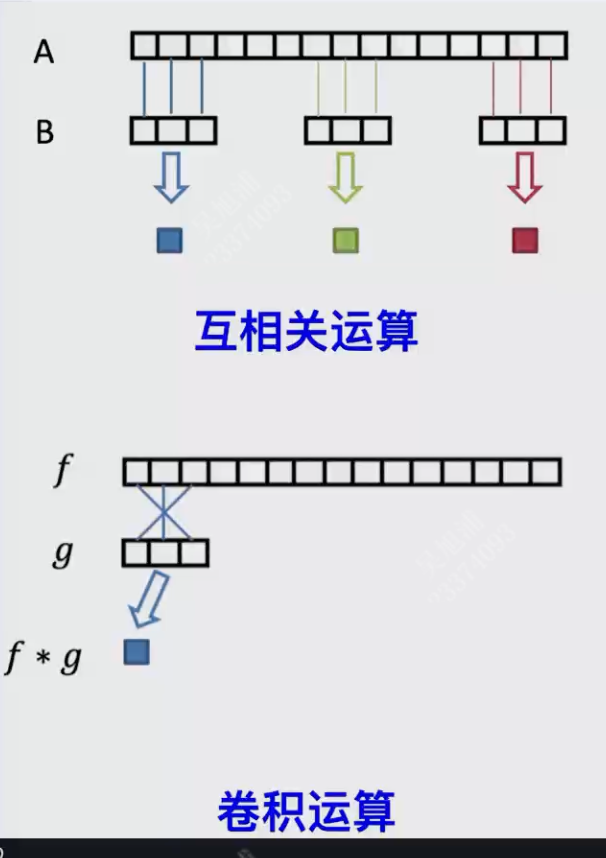


**互相关运算**（不翻转卷积核）：

$$(f \star g)[n] = \sum_{m=0}^{M-1} f[n + m] \cdot g[m]$$

**卷积运算**（翻转卷积核）：
$$(f * g)[n] = \sum_{m=0}^{M-1} f[n - m] \cdot g[m] = \sum_{m=0}^{M-1} f[n + m] \cdot g[M-1-m]$$

学习效果最后也就是一个翻转处理，所以最后是等价的，

什么时候用到卷积运算？
 - 卷积核很大的时候，用快速傅立叶变换变换fft进行加速
 - 但是现代cnn的发展是向一个小的卷积核去发展


#### <font color="#CCFF00">**为什么互相关运算可以实现特征的提取？**</font>

### <font color="#39FF14" size=6 >**互相关与余弦相似度**</font>

#### <font color="#CCFF00">**余弦相似度的数学定义**</font>

$x$ 和 $y$ 两个向量间的**余弦相似度**（Cosine Similarity）：

$$s \equiv \cos\theta = \frac{x^T y}{||x|| \cdot ||y||} = \frac{\sum_i x_i y_i}{\sqrt{\sum_i x_i^2} \cdot \sqrt{\sum_i y_i^2}}$$

<font color="#FF00A0">**关键洞察**</font>：如果两个向量具有**单位长度**（即 $||x|| = ||y|| = 1$），则：

$$s = \cos\theta = \sum_i x_i y_i = x^T y$$

此时余弦相似度简化为**向量的点积**（内积）！

### **<font color="#39FF14" size=6 >二维卷积</font>**

#### 二维离散卷积

对于矩阵$F$（大小$M \times N$）和卷积核$G$（大小$K_1 \times K_2$）：

$$(F * G)[i, j] = \sum_{m=0}^{K_1-1} \sum_{n=0}^{K_2-1} F[i-m, j-n] \cdot G[m, n]$$

实际CNN中使用互相关：

$$(F \star G)[i, j] = \sum_{m=0}^{K_1-1} \sum_{n=0}^{K_2-1} F[i+m, j+n] \cdot G[m, n]$$

区别也在于是否翻转卷积核（2D）

### **<font color="#39FF14" size=6 >卷积的三种形式：Valid、Same、Full</font>**


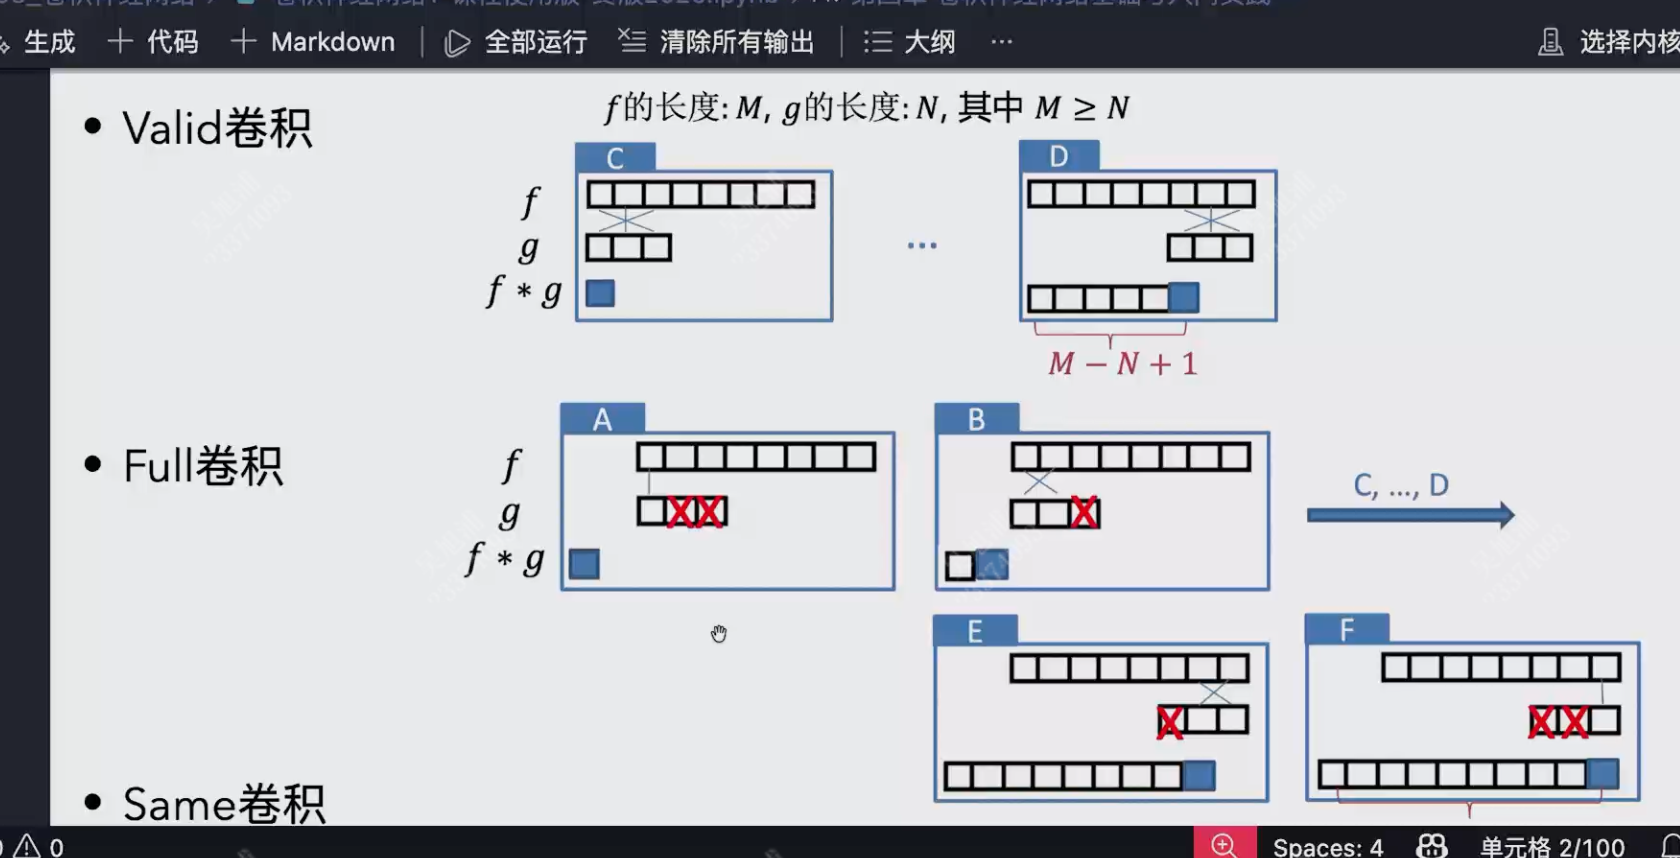

| 卷积类型 | 描述 | 输出尺寸 | 特点 |
|:--------:|:----:|:--------:|:----:|
| **Valid** | 不使用填充 | $(M-K+1) \times (N-K+1)$ | 不扩展边界，输出最小 |
| **Same** | 使用填充使输出尺寸与输入相同 | $M \times N$ | 零填充，保持空间尺寸 |
| **Full** | 完全填充 | $(M+K-1) \times (N+K-1)$ | 最大扩展，输出最大 |

### **<font color="#39FF14" size=6 >感受野：从局部到全局的视野扩展</font>**

#### <font color="#CCFF00">**什么是感受野？</font>**

<font color="#FF00A0" >**感受野（Receptive Field）**</font>：神经网络中某个神经元能够"看到"的原始输入图像的区域大小。

💡 **核心洞察**：随着网络加深，每个神经元的**感受野逐渐扩大**，从看**局部细节**到看**全局语义**！

#### <font color="#CCFF00">**感受野的计算**</font>

##### <font color="#CCFF00">**递推公式（从后往前）**</font>

设 $RF_l$表示第 $l$ 层一个神经元在**特征图**上的感受野边长，则回溯公式为：

$$RF_{l-1} = (RF_l - 1) \times s_l + k_l$$

其中：
- $s_l$：第 $l$ 层（即从 $l-1$ 到 $l$ 的变换）的步长
- $k_l$：第 $l$ 层的卷积核或池化窗口大小

---

## <font color="#FF6B00" >**📝 课堂练习 1**</font>

<font color="#FF00A0" size=4>**请完成《卷积神经网络1-课堂练习v1》中的 练习1：感受野计算**</font>

> 通过手工计算感受野，深入理解：
> - 感受野递推公式的应用
> - 网络深度与感受野大小的关系
> - "小卷积核 + 深层网络" 的设计思想

---

### **<font color="#39FF14" size=6 >池化操作（Pooling）</font>**

池化层对特征图的局部区域进行下采样，主要类型包括：

| 池化类型 | 操作 | 特点 |
|:--------:|:----:|:----:|
| **最大池化（Max Pooling）** | 取区域内的最大值 | 保留最强特征，常用 |
| **平均池化（Average Pooling）** | 取区域内的平均值 | 平滑特征，保留背景 |

<font color="#FF00A0" >**池化的作用**</font>：
1. **降维**：减少特征图尺寸，降低计算量
2. **增大感受野**：后续层能看到更大区域的信息
3. **提供平移不变性**：特征位置小幅变化不影响输出(最大值的移动在一定范围内，池化层最大值仍然不变)
4. **防止过拟合**：减少特征数量，提高泛化能力


#### 池化操作的尺寸计算

输出尺寸公式：
$$\text{Output Size} = \left\lfloor \frac{M - K}{S} \right\rfloor + 1$$

其中：
- $M$：输入尺寸
- $K$：池化核大小
- $S$：步长（stride）（池化核边长）


### **<font color="#39FF14" size=6 >卷积层 vs 全连接层：参数量对比</font>**

假设输入为 $32 \times 32$ 的灰度图像，输出为 $28 \times 28$ 的特征图：

**全连接层方案**（将图像展平）：
- 输入：$32 \times 32 = 1024$ 个神经元
- 输出：$28 \times 28 = 784$ 个神经元
- 参数量：$1024 \times 784 = 802,816$

**卷积层方案**（使用 $5 \times 5$ 卷积核）：
- 卷积核大小：$5 \times 5 = 25$ 个参数
- 通道：$c$ 个通道
- 总参数量：$ 25 \times c $

### **<font color="#39FF14" size=6 >卷积神经网络的核心特点</font>**

#### CNN vs MLP 对比

| 特性 | MLP（多层感知机） | CNN（卷积神经网络） |
|:----:|:----------------:|:-------------------:|
| **连接方式** | 全连接 | 局部连接 |
| **参数共享** | 无 | 卷积核权值共享 |
| **空间信息** | 丢失（展平后） | 保留 |
| **平移不变性** | 无 | 有 |
| **参数量** | 巨大 | 大幅减少 |
| **适用数据** | 表格数据 | 图像数据 |

💡 <font color="#FF00A0" >**关键洞察**</font>：CNN通过卷积操作实现了**特征提取**（Featurizer），将原始像素转换为有意义的特征表示。卷积核是学习得到的，通过多轮次的训练，卷积核学会如何进行特征提取可以更好的完成最终任务。

### **<font color="#39FF14" size=6 >回顾：从生物视觉到卷积神经网络</font>**

#### <font color="#CCFF00">**Hubel & Wiesel的发现 → CNN的实现**</font>

回顾Hubel & Wiesel的生物学发现，与CNN的对应关系：

| 生物学发现 | CNN实现 | 直观理解 |
|:----------:|:-------:|:--------:|
| **简单细胞**检测局部边缘 | **卷积核**检测特定方向的边缘 | 如检测水平线、垂直线的核 |
| **不同细胞**对不同方向/频率敏感 | **不同卷积核**学习不同特征 | 有的核检测横线，有的检测纹理 |
| **感受野**局部连接 | **卷积核**局部区域 | 3×3核只看9个像素，模仿视网膜局部感知 |
| **复杂细胞**的位置不变性 | **池化层** | 小幅平移不影响识别，如Max Pooling |
| **层级结构**（V1→V2→IT） | **深度网络结构** | 从简单到复杂的特征层次 |


💡 **重要区别**：生物神经元的连接是**进化固定**的（弱势的治疗方法），而CNN的卷积核是**数据驱动学习**的——同样的架构，学习不同数据，会得到不同的特征检测器！


##  <font color="#FFEA00" >**第2节 图像表示与通道概念**</font>

### **<font color="#39FF14" size=6 >图像的数字化表示</font>**

#### <font color="#CCFF00">**像素与像素值**</font>

图像由像素（Pixel）组成，每个像素是一个数值：

| 图像类型 | 通道数 | 像素值范围 | 说明 |
|:--------:|:------:|:----------:|:----:|
| **灰度图像** | 1 | 0 - 255 | 0=黑色, 255=白色 |
| **RGB彩色图像** | 3 | 0 - 255 | R=红, G=绿, B=蓝 |


8位能表示的状态数：$2^8 = 256$ 种（0 到 255）

💡 **RGB真彩色**：R/G/B 各用 8 位，共 24 位，可表示 $256^3 = 1677$ 万种颜色！“24位色”的由来

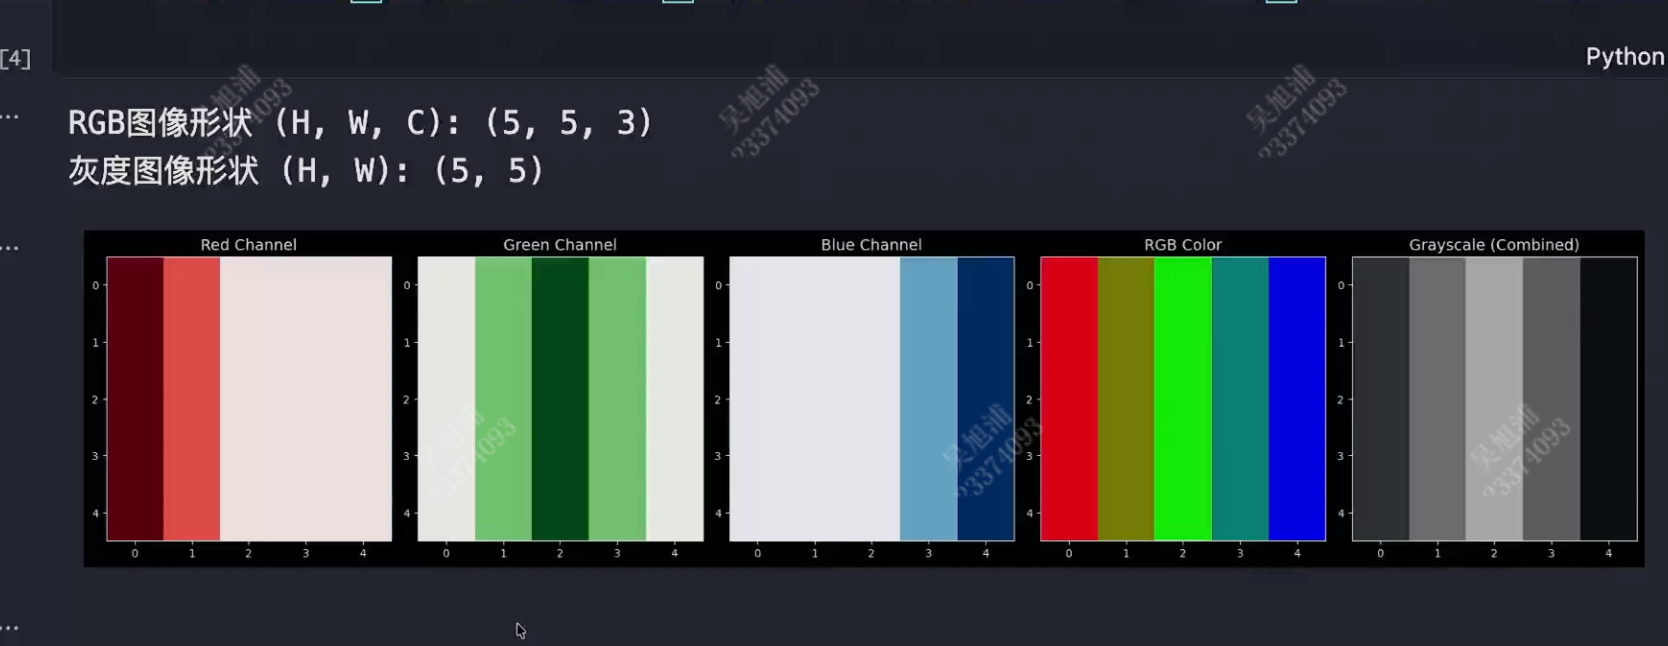


#### <font color="#CCFF00">**RGB vs 灰度图像**</font>

**灰度图像**：只有一个通道，每个像素表示亮度

**RGB彩色图像**：有三个通道，分别表示红、绿、蓝三种颜色的强度

$$\text{彩色图像} = \begin{bmatrix} R \ G \ B \end{bmatrix}$$

💡 **灰度转换**：可以通过加权平均将RGB转为灰度
$$\text{Gray} = 0.2126R + 0.7152G + 0.0722B$$

💡 公式中的权重（0.2126, 0.7152, 0.0722）正是基于人眼对不同颜色的敏感度（对绿色最敏感、红色次之，蓝色最弱），由国际电信联盟（ITU-R BT.709标准）制定。

#### <font color="#CCFF00">**数据格式：NCHW vs NHWC**</font>

不同框架使用不同的图像数据格式：

| 格式 | 维度顺序 | 使用框架 |
|:----:|:--------:|:--------:|
| **NCHW** | (Batch（批量大小）, Channel（3）, Height, Width) | PyTorch | 
| **NHWC** | (Batch, Height, Width, Channel) | TensorFlow |
| **HWC** | (Height, Width, Channel) | PIL图像 |

<font color="#FF00A0" >**注意**</font>：在PyTorch中处理图像时，需要确保格式正确！

#### <font color="#CCFF00">**PIL/Pillow图像处理库**</font>

**PIL**（Python Imaging Library）是Python最经典的图像处理库，现使用活跃分支 **Pillow**。

| 功能 | 说明 |
|:----:|:----:|
| **图像读写** | 支持JPG、PNG、BMP、GIF等几十种格式 |
| **基本变换** | 裁剪、缩放、旋转、翻转、调整亮度/对比度 |
| **格式转换** | RGB↔灰度、图像↔NumPy数组（HWC格式） |
| **绘图功能** | 画线、画框（目标检测）、添加文字 |

💡 **在深度学习中的用途**：数据预处理（读取图像、数据增强）、与PyTorch的`torchvision.transforms`配合、可视化辅助。

<font color="#FF00A0" >**PIL vs OpenCV对比**</font>：

| 特性 | PIL/Pillow | OpenCV |
|:----:|:----------:|:------:|
| **上手难度** | 简单，Pythonic | 较复杂，C++风格 |
| **颜色格式** | RGB（直观） | BGR（需转换） |
| **深度学习** | 与PyTorch配合好 | 需手动转换 |
| **适用场景** | 数据预处理 | 复杂CV算法、实时视频 |


In [2]:
# NCHW vs NHWC 格式转换示例

# 假设我们有一个PyTorch格式的图像 (NCHW)
nchw_image = np.random.rand(1, 3, 32, 32)  # 1张图，3通道，32x32像素
print(f"NCHW格式形状: {nchw_image.shape}")

# 转换为NHWC格式（TensorFlow使用）
nhwc_image = np.transpose(nchw_image, (0, 2, 3, 1))
print(f"NHWC格式形状: {nhwc_image.shape}")

# 转换回NCHW
nchw_back = np.transpose(nhwc_image, (0, 3, 1, 2))
print(f"转换回NCHW格式: {nchw_back.shape}")

# 使用PyTorch进行转换
tensor_nchw = torch.randn(1, 3, 32, 32)
tensor_nhwc = tensor_nchw.permute(0, 2, 3, 1)
print(f"\nPyTorch Tensor NCHW: {tensor_nchw.shape}")
print(f"PyTorch Tensor NHWC: {tensor_nhwc.shape}")

NCHW格式形状: (1, 3, 32, 32)
NHWC格式形状: (1, 32, 32, 3)
转换回NCHW格式: (1, 3, 32, 32)

PyTorch Tensor NCHW: torch.Size([1, 3, 32, 32])
PyTorch Tensor NHWC: torch.Size([1, 32, 32, 3])


### <font color="#39FF14" size=6>**多通道卷积：从输入通道到输出通道**</font>

#### <font color="#CCFF00">**Step 1：单通道输入 → 单通道输出（复习）**</font>

回顾单通道（灰度）图像的卷积：

```
输入图像: [1, H, W]     滤波器: [1, K, K]     输出特征图: [1, H', W']
              │                │                       │
              └──────────────→ 卷积运算 ──────────────┘
```

<font color="#FF00A0" >**参数说明**</font>：
- 输入通道 $C_{in} = 1$
- 滤波器形状：`[1, K, K]`（一个 $K \times K$ 的卷积核）
- 输出通道 $C_{out} = 1$

💡 **核心操作**：滤波器在图像上滑动，每个位置做**逐元素相乘再求和**，得到一个输出像素。

#### <font color="#CCFF00">**Step 2：多通道输入 → 单通道输出（关键过渡）**</font>

现在考虑彩色图像（如RGB三通道）：

<font color="#FF00A0" >**关键问题**</font>：输入有3个通道，怎么得到**一个**输出通道？
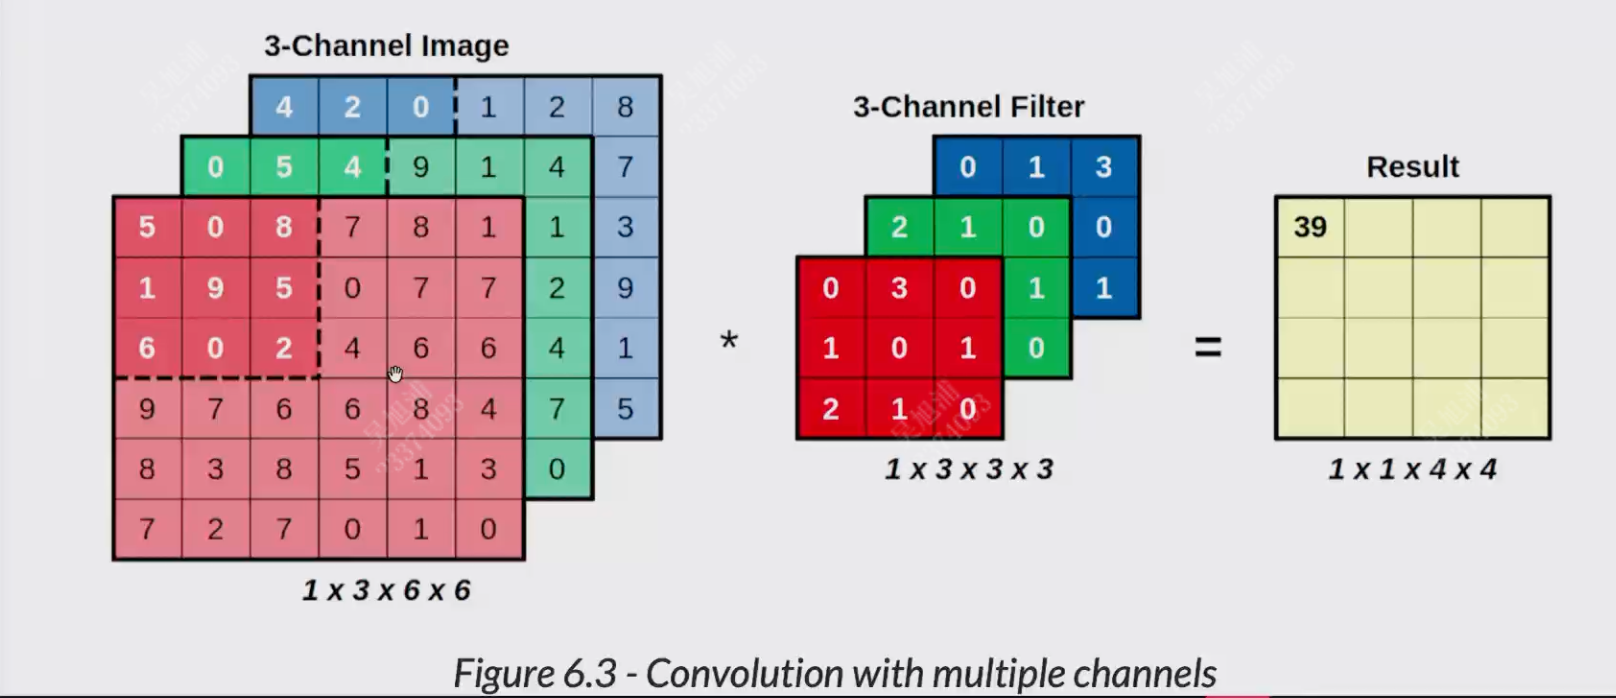
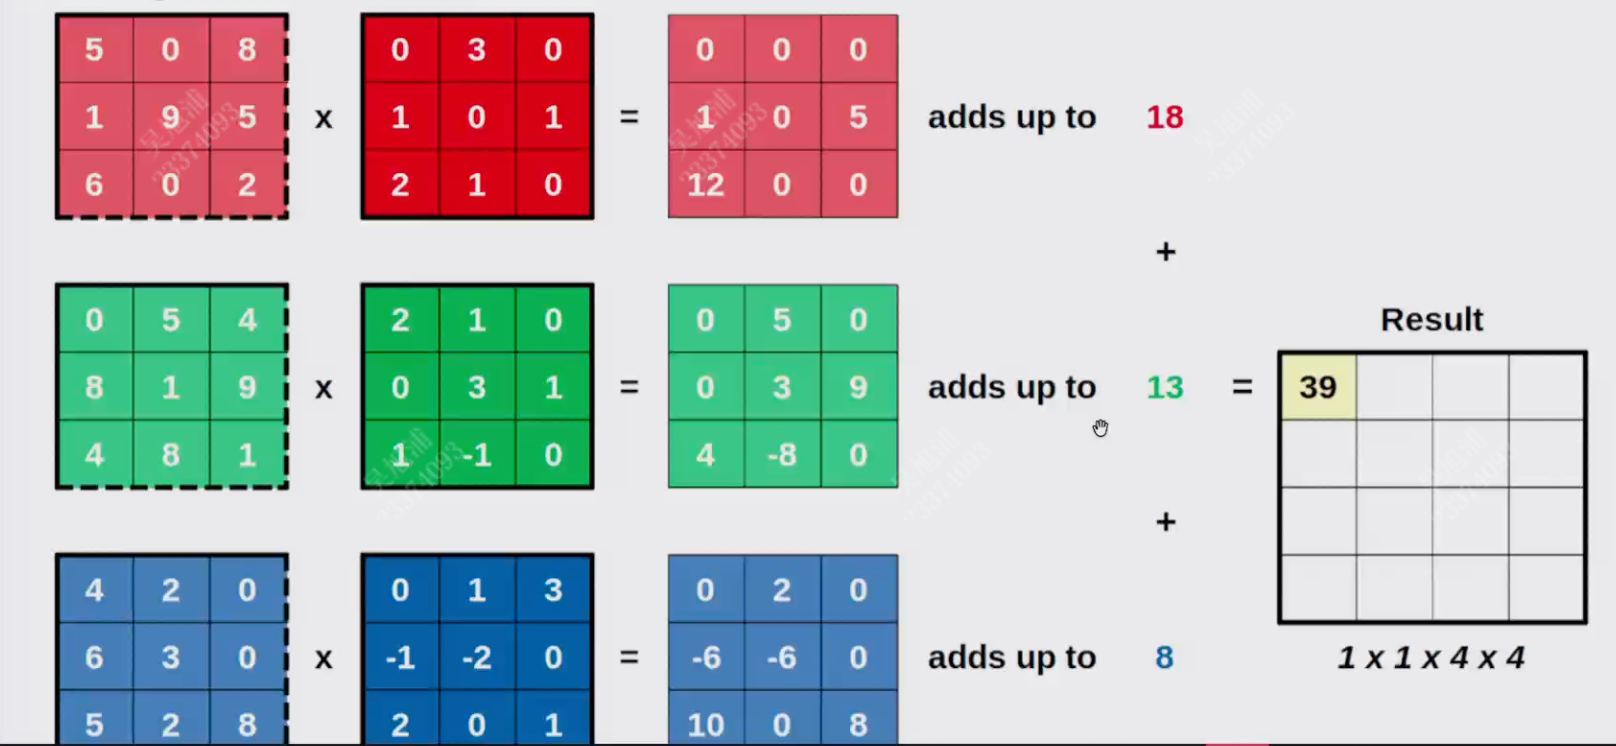

**解决思路**：
1. 滤波器也要有3个通道（与输入通道数相同）
2. 每个通道的卷积核分别与对应输入通道卷积
3. **将各通道结果相加**，得到一个标量 → 这就是输出特征图的**一个像素**

**数学表达**（一个输出像素的计算）：
$$Output[0, y, x] = \sum_{c=0}^{C_{in}-1} \sum_{i=0}^{K-1} \sum_{j=0}^{K-1} Input[c, y+i, x+j] \times Filter[c, i, j]$$

<font color="#FF00A0" >**重要结论**</font>：
- 滤波器形状：`[C_in, K, K]`（注意：这里是$C_{in}$不是$C_{out}$！）
- **$C_{in}$个卷积核产生1个输出通道**


#### <font color="#CCFF00">**Step 3：多通道输入 → 多通道输出（最终形态）**</font>

如果需要输出**多个通道**（如同时检测边缘、纹理、颜色等不同特征），怎么办？

<font color="#FF00A0" >**核心思想**</font>：**使用多组滤波器，每组产生一个输出通道**

```
输入: [C_in, H, W]     滤波器组: [C_out, C_in, K, K]     输出: [C_out, H', W']
                              │
                              ├── 滤波器0: [C_in, K, K] ──→ 输出通道0
                              ├── 滤波器1: [C_in, K, K] ──→ 输出通道1
                              ├── 滤波器2: [C_in, K, K] ──→ 输出通道2
                              └── 滤波器...
```

**具体例子**（3通道输入 → 16通道输出）：

| 组件 | 形状 | 说明 |
|:---|:---|:---|
| 输入图像 | `[3, 32, 32]` | 3通道，32×32像素 |
| 滤波器组 | `[16, 3, 3, 3]` | 16个滤波器，每个3通道，3×3大小 |
| 输出特征图 | `[16, 30, 30]` | 16通道，30×30像素（无填充）|

<font color="#FF00A0" size=4>**最终结论**</font>：

| 参数 | 符号 | 维度说明 |
|:---|:---:|:---|
| 输入通道 | $C_{in}$ | 输入图像的通道数 |
| 输出通道 | $C_{out}$ | **滤波器的数量（组数）** |
| 滤波器形状 | - | `[C_out, C_in, K, K]` |
| 输出特征图 | - | `[C_out, H', W']` |

💡 **一句话总结**：**输出通道数 = 滤波器组数**，每个滤波器组包含 $C_{in}$ 个卷积核。

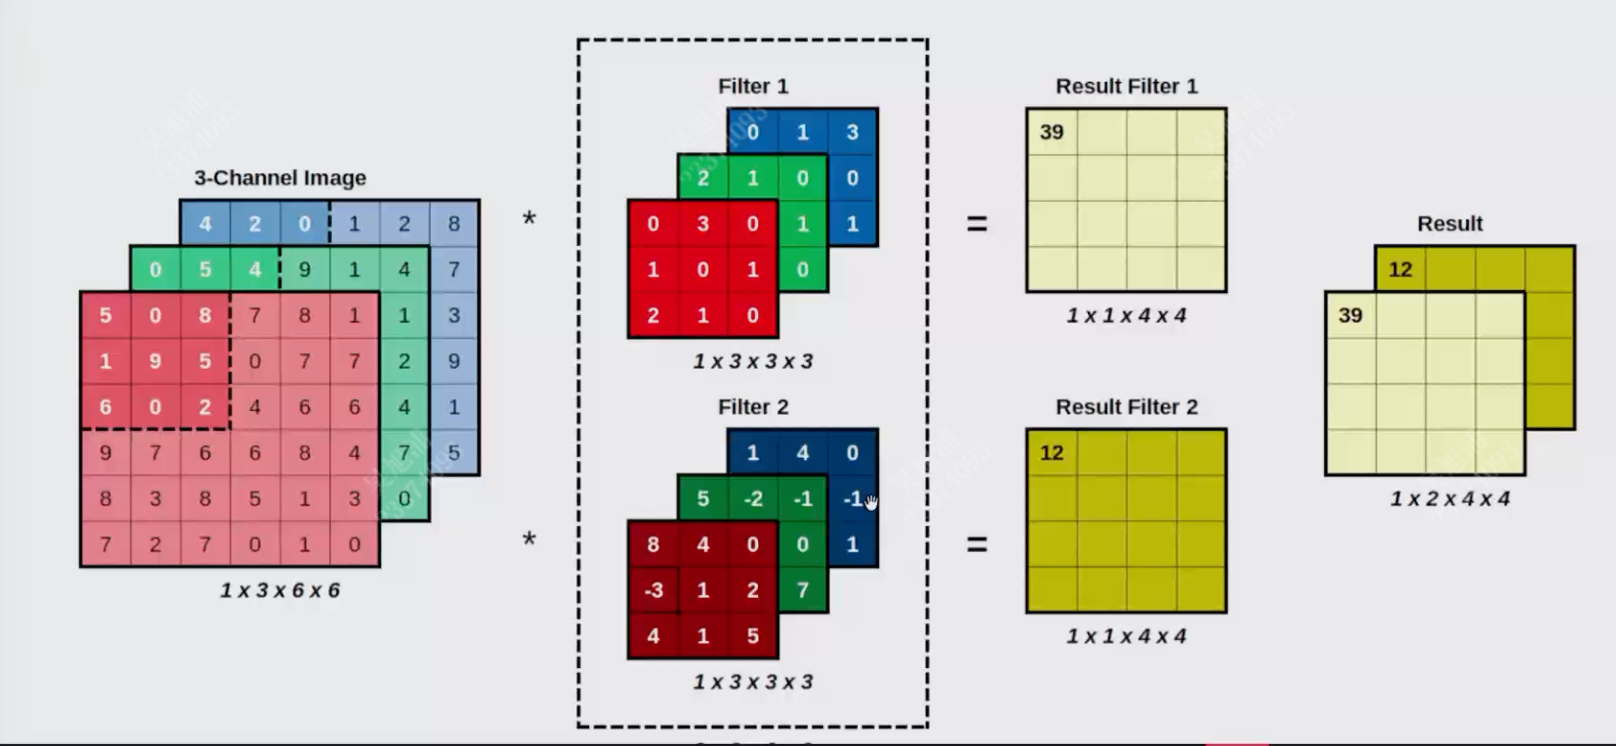

#### <font color="#CCFF00">**卷积层维度变化总结**</font>

| 维度 | 输入 | 滤波器 | 输出 |
|:----:|:----:|:------:|:----:|
| **Batch** | N | - | N |
| **Channel**（通道数） | $C_{in}$ | $C_{out}$ × $C_{in}$ | $C_{out}$ |
| **Height** | H | K | H - K + 1 |
| **Width** | W | K | W - K + 1 |

其中：
- $C_{in}$：输入通道数
- $C_{out}$：输出通道数（滤波器数量）
- K：滤波器空间尺寸（假设为正方形）

### <font color="#39FF14" size=6>**数据预处理：从归一化到标准化**</font>

#### <font color="#CCFF00">**为什么需要预处理？**</font>

机器学习：归一化是在涉及距离计算的时候，做处理就会把他映射到[0, 1]之间。

图像像素值范围是 **[0, 255]**，直接输入神经网络会带来问题：

<font color="#FF00A0" >**主要问题**</font>：
- **梯度下降效率低**：大数值导致梯度更新不稳定
- **数值溢出风险**：激活函数（如sigmoid）对大数值敏感
- **特征尺度不一致**：不同通道或数据集间差异大

💡 **解决思路**：将数据映射到适合模型训练的范围

#### <font color="#CCFF00">**第一层：基础缩放 — Min-Max归一化**</font>

📌 **最简单的预处理方法** — 将像素值线性缩放到[0, 1]

**公式**：
$$x' = \frac{x}{255}$$


✅ **优点**：
- 实现零成本，PyTorch的`ToTensor()`自动完成
- 不依赖数据集统计，即插即用

⚠️ **局限**：
- 假设数据分布均匀，未考虑统计特性
- 不同数据集的均值/方差可能差异很大

#### <font color="#CCFF00">**第二层：进阶处理 — Z-Score标准化**</font>

📌 **深度学习中更常用的方法** — 考虑数据的分布特性

##### <font color="#00ffbf">**为什么需要标准化？**</font>

Min-Max归一化的**不足**：
- 不同批次数据的均值可能不同 → 模型学习不稳定
- 极端值会影响缩放效果

**标准化的核心思想**：
> 让数据服从**标准正态分布**（均值为0，标准差为1）

##### <font color="#00ffbf">**公式与解释**</font>

$$x' = \frac{x - \mu}{\sigma}$$

其中：
- $\mu$：数据集的**均值**（mean）— 控制分布的中心位置
- $\sigma$：数据集的**标准差**（standard deviation）— 控制分布的离散程度

<font color="#FF00A0" >**标准化的优势**</font>：
- ✅ **均值为0** → 梯度下降收敛更快
- ✅ **方差为1** → 数值稳定性提升
- ✅ **消除量纲差异** → 多特征融合更公平

##### <font color="#FF00A0" size=4>**⚠️ 关键原则：统计量只能来自训练集！**</font>

**错误做法**：用全部数据（训练集+验证集+测试集）计算$\mu$和$\sigma$

**正确做法**：
```
1. 从训练集计算 μ_train, σ_train
2. 保存这两个值（作为预处理参数）
3. 训练/验证/测试/新数据，都用这两个值标准化
```

<font color="#FF00A0" >**为什么？**</font>
- 模拟真实场景：新数据在训练时不可见
- 避免信息泄露：测试集统计信息不应影响训练
- 确保一致性：所有数据用同一标准处理

💡 **RGB图像的特殊处理**：
需要为 **R、G、B三个通道分别计算** $\mu$和$\sigma$
```python
# PyTorch示例：使用ImageNet预训练模型的统计量
transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],  # R, G, B通道均值
    std=[0.229, 0.224, 0.225]     # R, G, B通道标准差
)
```

#### <font color="#CCFF00">**第三层：特殊场景 — 对称缩放**</font>

📌 **特定需求下的替代方案**

**公式**：
$$x' = \left(\frac{x}{255} - 0.5\right) / 0.5 = \frac{x}{127.5} - 1$$

**适用场景**：
- 特定网络架构要求零中心输入（如早期GAN）
- 需要使用tan_h等对称激活函数的输出层


#### <font color="#CCFF00">**方法对比与选择指南**</font>

| 方法 | 复杂度 | 数据依赖 | 核心特点 | 推荐场景 |
|:---|:---:|:---:|:---|:---|
| **Min-Max** | ⭐ 简单 | ❌ 固定 | 快速上手，即插即用 | 快速实验、Baseline |
| **Z-Score** | ⭐⭐ 中等 | ✅ 需统计 | **考虑分布，训练更稳定** | **深度学习（推荐）** |
| **对称缩放** | ⭐ 简单 | ❌ 固定 | 零中心，特定需求 | GAN、对称激活函数 |

---

💡 **实践建议**：

<font color="#39FF14" >**初学者路线**</font>：
1. 先用 **Min-Max** 建立直觉 → 理解为什么需要预处理
2. 进阶到 **Z-Score** → 掌握深度学习的标准做法

<font color="#39FF14" >**正式项目**</font>：
- 优先使用 **Z-Score标准化**
- 必须保存训练集的$\mu$和$\sigma$用于后续推理
- 使用预训练模型时，**严格使用其预训练时的统计量**

##  <font color="#FFEA00" >**第3节 典型的卷积神经网络架构**</font>

### **<font color="#39FF14" size=6 >典型卷积块（Convolutional Block）</font>**

一个典型的卷积块包含三个操作：

```
输入 → [卷积层] → [激活函数] → [池化层] → 输出
```


### **<font color="#39FF14" size=6 >典型CNN架构组成部分</font>**
1. **特征提取器（Featurizer）**：多个卷积块堆叠
2. **分类器（Classifier）**：全连接层 + 输出层

### **<font color="#39FF14" size=6 >LeNet-5（1998）</font>**

Yann LeCun开发的经典CNN架构，用于手写数字识别（MNIST）：

**架构细节**：

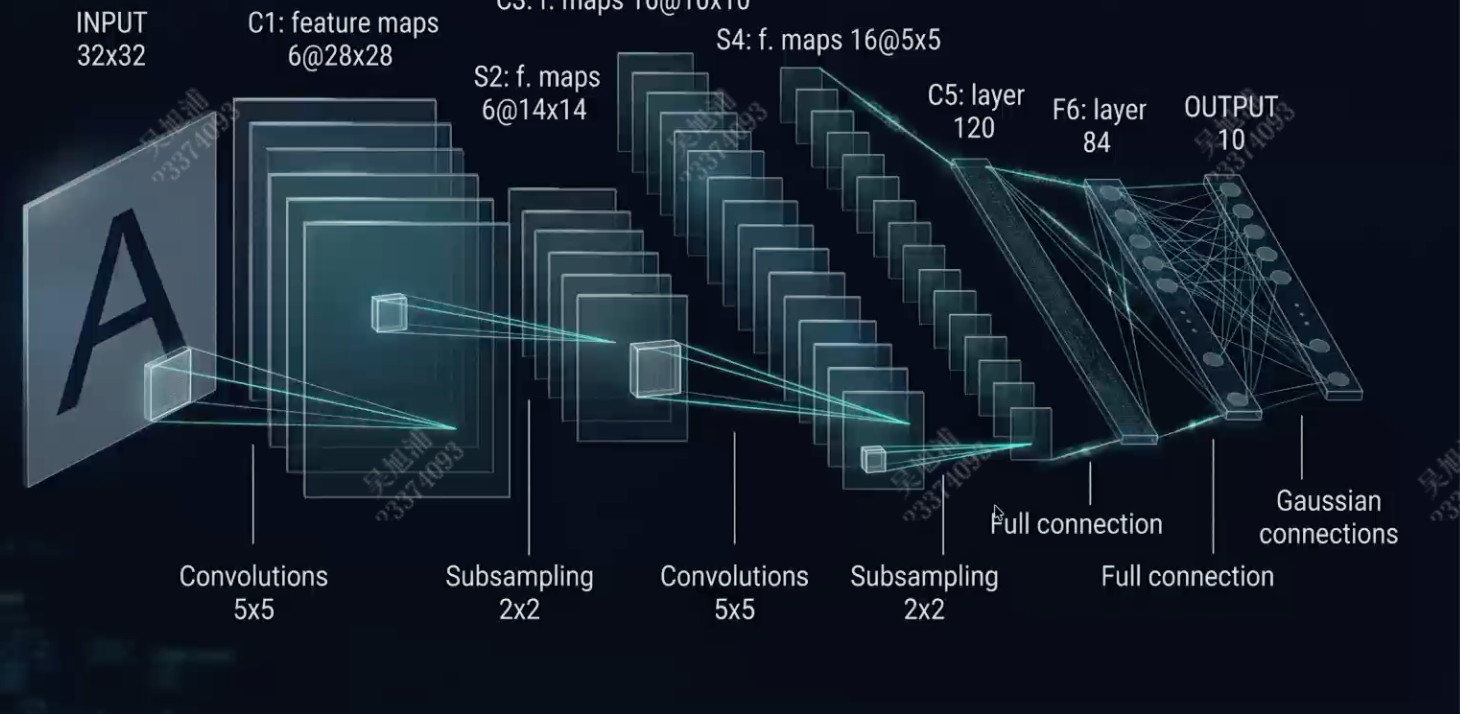

```
输入: 1@32x32 (单通道32x32)

C1: 卷积层   1@32x32 → 6@28x28 (5x5卷积核)(6 * 1 * 5 * 5)
S2: 池化层   6@28x28 → 6@14x14 (2x2平均池化)(6 * 2 * 2)
C3: 卷积层   6@14x14 → 16@10x10 (5x5卷积核)(16 * 6 * 5 * 5)
S4: 池化层   16@10x10 → 16@5x5 (2x2平均池化)(16 * 2 * 2)
C5: 卷积层   16@5x5 → 120@1x1 (5x5卷积核)(120 * 16 * 5 * 5)
F6: 全连接   120 → 84 (84个神经元)
F7: 全连接 84 → 10 (10个)
输出: 全 →10 (10个数字类别)
```

In [3]:
# LeNet-5 PyTorch实现
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # 特征提取器
        self.features = nn.Sequential(
            # C1: 1@32x32 -> 6@28x28
            nn.Conv2d(1, 6, kernel_size=5, padding=0),
            nn.ReLU(),
            # S2: 6@28x28 -> 6@14x14
            nn.MaxPool2d(kernel_size=2, stride=2),
            # C3: 6@14x14 -> 16@10x10
            nn.Conv2d(6, 16, kernel_size=5, padding=0),
            nn.ReLU(),
            # S4: 16@10x10 -> 16@5x5
            nn.MaxPool2d(kernel_size=2, stride=2),
            # C5: 16@5x5 -> 120@1x1
            nn.Conv2d(16, 120, kernel_size=5, padding=0),
            nn.ReLU(),
        )
        # 分类器
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 创建模型并统计参数量
model_lenet = LeNet5(num_classes=10)
total_params = sum(p.numel() for p in model_lenet.parameters())

print("LeNet-5 架构:")
print(model_lenet)
print(f"\n总参数量: {total_params:,}")

# 测试前向传播
x = torch.randn(1, 1, 32, 32)
output = model_lenet(x)
print(f"\n输入形状: {x.shape}")
print(f"输出形状: {output.shape}")

LeNet-5 架构:
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): ReLU()
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)

总参数量: 61,706

输入形状: torch.Size([1, 1, 32, 32])
输出形状: torch.Size([1, 10])


### **<font color="#39FF14" size=6 >AlexNet</font>**

#### <font color="#CCFF00">**AlexNet的三层结构**</font>

AlexNet架构包含三个主要部分：**features**、**avgpool**和**classifier**：

| 部分 | 功能 | 包含层 |
|:----:|:----:|:-------|
| **features** | 特征提取器 | 5个卷积块（卷积+ReLU+池化） |
| **avgpool** | 自适应池化 | AdaptiveAvgPool2d(6,6) |
| **classifier** | 分类器 | 3个全连接层 + Dropout |

<font color="#FF00A0">**关键点**</font>：
- **features**部分包含五个典型的卷积块，对应传统CNN的'featurizer'
- **avgpool**使用自适应池化，将任意尺寸输入转换为固定6×6输出
- **classifier**部分包含两个隐藏层（各4096神经元）和一个输出层（1000类）

In [4]:
# AlexNet架构加载与解析
from torchvision.models import alexnet

# 加载AlexNet架构（不加载预训练权重）
model = alexnet(pretrained=False)
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

#### <font color="#CCFF00">**逐层解析**</font>

**Features部分（卷积层）：**
```
Conv2d(3, 64, kernel_size=11, stride=4)   # 输入3通道，输出64通道，11×11卷积核
ReLU(inplace=True)
MaxPool2d(kernel_size=3, stride=2)
Conv2d(64, 192, kernel_size=5, padding=2) # 64→192通道，5×5卷积核
ReLU(inplace=True)
MaxPool2d(kernel_size=3, stride=2)
Conv2d(192, 384, kernel_size=3, padding=1)
ReLU(inplace=True)
Conv2d(384, 256, kernel_size=3, padding=1)
ReLU(inplace=True)
Conv2d(256, 256, kernel_size=3, padding=1)
ReLU(inplace=True)
MaxPool2d(kernel_size=3, stride=2)
```

**Adaptive Pooling：**
- 输入：经过features后的特征图（任意尺寸）
- 输出：固定为(256, 6, 6)
- 作用：允许输入图像有不同尺寸，最终输出固定大小

**Classifier部分（全连接层）：**
```
Dropout(p=0.5)
Linear(9216, 4096)   # 输入：256×6×6=9216
ReLU(inplace=True)
Dropout(p=0.5)
Linear(4096, 4096)
ReLU(inplace=True)
Linear(4096, 1000)   # 输出：1000类（ImageNet类别数）
```

### **<font color="#39FF14" size=6 >自适应池化（Adaptive Pooling）</font>**

#### <font color="#CCFF00">**什么是自适应池化？**</font>

**AdaptiveAvgPool2d**是一种特殊的池化层，它不要求指定池化核大小，而是直接指定**输出尺寸**。

**作用**：
- 允许使用不同尺寸的输入图像
- 确保分类器部分始终接收到固定尺寸的特征图

In [5]:
# 自适应池化示例
import torch
import torch.nn.functional as F

# 两个不同尺寸的特征图
feature_map_1 = torch.randn(16, 256, 32, 32)  # 32×32
feature_map_2 = torch.randn(16, 256, 12, 12)  # 12×12

# 使用自适应池化统一到6×6
output_1 = F.adaptive_avg_pool2d(feature_map_1, output_size=(6, 6))
output_2 = F.adaptive_avg_pool2d(feature_map_2, output_size=(6, 6))

print(f"输入1: {feature_map_1.shape} → 输出: {output_1.shape}")
print(f"输入2: {feature_map_2.shape} → 输出: {output_2.shape}")
print("\n无论输入尺寸如何，输出始终是 (batch, 256, 6, 6)")

输入1: torch.Size([16, 256, 32, 32]) → 输出: torch.Size([16, 256, 6, 6])
输入2: torch.Size([16, 256, 12, 12]) → 输出: torch.Size([16, 256, 6, 6])

无论输入尺寸如何，输出始终是 (batch, 256, 6, 6)




## <font color="#FF6B00" >**📝 课堂练习 2**</font>

<font color="#FF00A0" size=4>**请完成《卷积神经网络1-课堂练习v1》中的 练习2：简易CNN架构设计**</font>

> 通过设计MNIST分类网络，掌握：
> - CNN架构设计的基本原则
> - 特征图尺寸变化的计算方法
> - 网络参数量估算
> - 通道数变化的设计理念



##  <font color="#FFEA00" >**第4节 网络配置与损失函数应匹配**</font>

### **<font color="#39FF14" size=6 >交叉熵损失（Cross-Entropy Loss）</font>**

对于多分类问题，使用**交叉熵损失**：

$$L = -\frac{1}{N} \sum_{n=1}^{N} \log h_{k^*}(x^{(n)})$$

对于每个样本，只看正确样本的概率，再取负对数，最后取平均。


### <font color="#39FF14" size=6 >**网络架构与损失函数匹配表**</font>

|                             | BCE Loss           | <font color="#FF00A0">**BCE With Logits Loss**</font> | NLL Loss                   | <font color="#FF00A0" size=4>**Cross-Entropy Loss**</font> |
| :-------------------------- | :----------------- | :------------------- | :------------------------- | :----------------- |
| **Classification**          | binary             | binary               | multiclass                 | multiclass         |
| **Input (each data point)** | probability        | logit                | array of log probabilities | array of logits    |
| **Label (each data point)** | float (0.0 or 1.0) | float (0.0 or 1.0)   | long (class index)         | long (class index) |
| **Model's last layer**      | Sigmoid            | -                    | LogSoftmax                 | -                  |
| **weight argument**         | not class weights  | not class weights    | class weights              | class weights      |
| **pos_weight argument**     | n/a                | "weighted" loss      | n/a                        | n/a                |



---

### **推荐损失函数**

| 问题类型 |    推荐损失函数     | 模型最后一层 |     标签类型      |
| :------: | :-----------------: | :----------: | :---------------: |
|  二分类  | `BCEWithLogitsLoss` |  无激活函数  | `float` (0.0/1.0) |
|  多分类  | `CrossEntropyLoss`  |  无激活函数  | `long` (类别索引) |

### ⚠️ **重要提示**

1. **数值稳定性**：推荐使用 `BCEWithLogitsLoss` 和 `CrossEntropyLoss`，它们在内部将激活函数与损失计算融合，数值更稳定

2. **类别不平衡**：
   - `BCEWithLogitsLoss`：使用 `pos_weight` 参数调整正样本权重
   - `CrossEntropyLoss`：使用 `weight` 参数给不同类别设置权重



### <font color="#CCFF00">**处理数据集类别不平衡问题的策略**</font>

##### <font color="#00ffbf">**为什么需要weight和pos_weight？**</font>

在实际数据集中，不同类别的样本数量往往**不均衡**：

| 场景 | 类别分布示例 | 导致的问题 |
|:--|:--|:--|
| 医疗诊断 | 正常: 9900, 患病: 100 | 模型全部预测为"正常"也能达到99%准确率 |
| 欺诈检测 | 正常交易: 99900, 欺诈: 100 | 模型学不到欺诈的特征 |
| 目标检测 | 背景: 大量, 目标: 少量 | 模型倾向于预测为背景 |

<font color="#FF00A0">**核心问题**</font>：模型会被"多数类"主导，对"少数类"的识别能力很差。

---

##### <font color="#00ffbf">**两个参数的区别**</font>

| 参数 | 适用损失函数 | 适用场景 | 作用 |
|:--|:--|:--|:--|
| **pos_weight** | `BCEWithLogitsLoss` | 二分类（正/负样本）| 增加正样本（少数类）的权重 |
| **weight** | `CrossEntropyLoss`<br>`NLLLoss` | 多分类（≥3个类别）| 给每个类别分别设置权重 |

---

##### <font color="#00ffbf">**为什么需要指定这两个参数？**</font>

**默认情况**（不指定weight）：
```python
criterion = nn.CrossEntropyLoss()  # 所有类别权重相等
```

**会发生的问题**：
- 模型学到：总是预测为多数类
- 正类/少数类召回率可能接近0%
- 准确率虚高但**实际应用价值为零**


##### <font color="#00ffbf">**如何计算和设置权重？**</font>

##### **基于样本比例的倒数（最常用）**

```python
import torch
import torch.nn as nn

# ========== 二分类：pos_weight ==========
# 假设正样本:负样本 = 100:900
num_positive = 100
num_negative = 900
pos_weight = num_negative / num_positive  # = 9.0

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight])
)

# ========== 多分类：weight ==========
# 假设3个类别，样本数为 [1000, 200, 100]
class_counts = torch.tensor([1000.0, 200.0, 100.0])

# 权重与类别频率成反比
weights = 1.0 / class_counts
weights = weights / weights.sum() * len(class_counts)  # 归一化

criterion = nn.CrossEntropyLoss(weight=weights)
```


##### <font color="#00ffbf">**⚠️ 关键注意事项**</font>

1. **weight vs pos_weight 不要混淆**

| 问题类型 | 使用参数 | 代码示例 |
|:--|:--|:--|
| 二分类 | `pos_weight` | `BCEWithLogitsLoss(pos_weight=...)` |
| 多分类 | `weight` | `CrossEntropyLoss(weight=...)` |

2. **过拟合风险**：权重设置过大可能导致对少数类过拟合，建议通过验证集调参

---

##### <font color="#00ffbf">**最佳实践总结**</font>

损失函数中的`weight`/`pos_weight`参数可与`WeightedRandomSampler`搭配使用，达到平衡数据种类的目的。但要注意防止过度纠偏的情况发生。

| 场景 | 推荐方案 | 备注 |
  |------|----------|------|
  | 一般偏斜（1:10 ~ 1:100） | 只用 `WeightedRandomSampler` | 最稳定，无需改损失函数 |
  | 类别极多且偏斜不一 | 只用 `CrossEntropyLoss` 的 `weight` 参数 | Sampler 难以处理多类复杂比例 |
  | 极度偏斜（>1:1000） | 优先 `WeightedRandomSampler` + 可选轻微 `weight`/`pos_weight` 微调 | `weight`/`pos_weight` 用较小值（如 0.5 而非 0.001）做微调 |
  | 二分类不平衡 | `BCEWithLogitsLoss` 的 `pos_weight` 更直观 | 直接对应"正样本权重"的语义 |
  | 需要精确控制每类影响 | `CrossEntropyLoss` 的 `weight` 参数 | 可精确指定每类的损失系数 |


**简单决策流程**

  - 严重偏斜？
      - **是，且是二分类** → `pos_weight`（简单直接）
      - **是，且是多分类** → `WeightedRandomSampler`（推荐）
          - 或：`Sampler` + 轻微 `weight`/`pos_weight` 微调
      - **否（<1:10）** → 啥都不用，或用 `Sampler` 轻微平衡

  **一句话建议**：新手优先用 `WeightedRandomSampler`，简单且不易出错。


##  <font color="#FFEA00" >**第5节 PyTorch实现CNN图像分类（完整流程）**</font>

### **<font color="#39FF14" size=6 >完整图像分类流程</font>**

本节课我们将使用参考书中的完整流程实现CNN图像分类，包括：

1. **数据集生成**：使用线条图像生成数据集
2. **数据集分割**：训练/验证/测试集划分
3. **数据变换**：Compose组合多个变换
4. **数据加载**：使用WeightedRandomSampler处理类别不平衡
5. **模型定义**：CNN架构设计
6. **训练流程**：完整的训练、验证、测试循环
7. **模型性能评估**：使用分类指标全面评估模型性能

#### <font color="#CCFF00">**步骤1：生成数据集</font>**

In [6]:
# 步骤1：生成线条图像数据集
# 类别：0=平行线(水平/垂直), 1=对角线(左斜/右斜)

def generate_line_dataset(n_images=300, img_size=5, seed=13):
    """
    生成线条图像数据集
    返回: images (NCHW格式), labels
    """
    np.random.seed(seed)
    images = []
    labels = []
    
    for _ in range(n_images):
        img = np.zeros((img_size, img_size), dtype=np.uint8)
        label = np.random.randint(0, 2)  # 0或1
        
        if label == 0:  # 平行线
            if np.random.rand() > 0.5:  # 水平线
                row = np.random.randint(img_size)
                img[row, :] = 255
            else:  # 垂直线
                col = np.random.randint(img_size)
                img[:, col] = 255
        else:  # 对角线
            if np.random.rand() > 0.5:  # 左斜\\
                for i in range(img_size):
                    if i < img_size:
                        img[i, i] = 255
            else:  # 右斜/
                for i in range(img_size):
                    img[i, img_size-1-i] = 255
        
        images.append(img)
        labels.append(label)
    
    # 转换为NCHW格式 (Batch, Channel, Height, Width)
    images = np.array(images)[:, np.newaxis, :, :]  # 添加通道维度
    labels = np.array(labels)
    
    return images, labels

# 生成数据集
images, labels = generate_line_dataset(n_images=300, img_size=5, seed=666)

print(f"数据集大小: {len(images)}")
print(f"图像形状: {images[0].shape} (NCHW格式)")
print(f"类别分布: 类别0={sum(labels==0)}, 类别1={sum(labels==1)}")
print(f"像素值范围: [{images.min()}, {images.max()}]")

数据集大小: 300
图像形状: (1, 5, 5) (NCHW格式)
类别分布: 类别0=154, 类别1=146
像素值范围: [0, 255]


#### <font color="#CCFF00">**步骤2：数据集分割</font>**

In [7]:
# 步骤2：数据集分割 - 使用索引分割器

def index_splitter(n, splits, seed=13):
    """
    按比例分割数据集索引
    splits: 分割比例列表，如[80, 20]表示80%训练，20%验证
    """
    idx = torch.arange(n)
    splits_tensor = torch.as_tensor(splits)
    
    # 计算每个分割的大小
    multiplier = n / splits_tensor.sum()
    splits_tensor = (multiplier * splits_tensor).long()
    
    # 处理舍入误差
    diff = n - splits_tensor.sum()
    splits_tensor[0] += diff
    
    # 随机分割
    torch.manual_seed(seed)
    return torch.utils.data.random_split(idx, splits_tensor)

# 将numpy数组转换为tensor
x_tensor = torch.as_tensor(images / 255.0).float()  # 归一化到[0,1]
y_tensor = torch.as_tensor(labels.reshape(-1, 1)).float()

print(f"特征张量形状: {x_tensor.shape}")
print(f"标签张量形状: {y_tensor.shape}")

# 分割为训练集和验证集 (80% / 20%)
train_idx, val_idx = index_splitter(len(x_tensor), [80, 20])

# 使用索引分割数据
x_train = x_tensor[train_idx.indices]
y_train = y_tensor[train_idx.indices]
x_val = x_tensor[val_idx.indices]
y_val = y_tensor[val_idx.indices]

print(f"\n训练集大小: {len(x_train)}")
print(f"验证集大小: {len(x_val)}")
print(f"训练集类别分布: 类别0={(y_train==0).sum()}, 类别1={(y_train==1).sum()}")
print(f"验证集类别分布: 类别0={(y_val==0).sum()}, 类别1={(y_val==1).sum()}")

特征张量形状: torch.Size([300, 1, 5, 5])
标签张量形状: torch.Size([300, 1])

训练集大小: 240
验证集大小: 60
训练集类别分布: 类别0=125, 类别1=115
验证集类别分布: 类别0=29, 类别1=31


#### <font color="#CCFF00">**步骤3：图像变换（Compose）</font>**

使用`torchvision.transforms.Compose`组合多个变换：

| 变换 | 作用 | 说明 |
|:----:|:----:|:----:|
| `ToPILImage` | 转为PIL图像 | 便于应用图像级变换 |
| `Resize` | 调整大小 | 统一图像尺寸 |
| `ToTensor` | 转为Tensor | 归一化到[0,1] |
| `Normalize` | 标准化 | 归一化到指定范围 |

In [8]:
# 步骤3：定义数据变换
from torchvision.transforms import Compose, ToTensor, Normalize, ToPILImage, Resize

# 训练集变换（归一化）
train_transform = Compose([
    Normalize(mean=(0.5,), std=(0.5,))  
])

# 验证集变换（归一化）
val_transform = Compose([
    Normalize(mean=(0.5,), std=(0.5,))  
])

print("训练集变换:")
print(train_transform)
print("\n验证集变换:")
print(val_transform)

# 测试变换
sample_img = x_train[0]  # (1, 5, 5)
transformed = train_transform(sample_img)
print(f"\n原始图像形状: {sample_img.shape}")
print(f"变换后形状: {transformed.shape}")
print(f"变换后值范围: [{transformed.min():.2f}, {transformed.max():.2f}]")


训练集变换:
Compose(
    Normalize(mean=(0.5,), std=(0.5,))
)

验证集变换:
Compose(
    Normalize(mean=(0.5,), std=(0.5,))
)

原始图像形状: torch.Size([1, 5, 5])
变换后形状: torch.Size([1, 5, 5])
变换后值范围: [-1.00, 1.00]


#### <font color="#CCFF00">**步骤4：自定义Dataset与DataLoader</font>**

In [9]:
# 步骤4：创建支持变换的自定义Dataset

class TransformedTensorDataset(Dataset):
    """
    支持变换的Tensor数据集
    """
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform
    
    def __getitem__(self, index):
        x = self.x[index]
        if self.transform:
            x = self.transform(x)
        return x, self.y[index]
    
    def __len__(self):
        return len(self.x)

# 创建数据集
train_dataset = TransformedTensorDataset(x_train, y_train, transform=train_transform)
val_dataset = TransformedTensorDataset(x_val, y_val, transform=val_transform)

print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")

# 测试
sample_x, sample_y = train_dataset[0]
print(f"\n样本特征形状: {sample_x.shape}")
print(f"样本标签: {sample_y}")

训练集: 240 样本
验证集: 60 样本

样本特征形状: torch.Size([1, 5, 5])
样本标签: tensor([1.])


#### <font color="#CCFF00">**步骤5：WeightedRandomSampler处理类别不平衡</font>**

In [10]:
# 步骤5：创建WeightedRandomSampler处理类别不平衡
from torch.utils.data import WeightedRandomSampler
import numpy as np

def make_balanced_sampler(y):
    """
    创建类别平衡的采样器
    少数类样本会被更频繁地采样
    返回: (sampler, sample_weights) 元组
    """
    # 计算每个类别的样本数
    classes, counts = y.unique(return_counts=True)
    print(f"类别: {classes.flatten().tolist()}")
    print(f"数量: {counts.tolist()}")
    
    # 计算权重：样本数少的类别权重大
    weights = 1.0 / counts.float()
    print(f"类别权重: {weights.tolist()}")
    
    # 为每个样本分配权重
    sample_weights = weights[y.squeeze().long()]
    
    # 创建采样器
    generator = torch.Generator()
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        generator=generator,
        replacement=True
    )
    return sampler, sample_weights  # 返回sample_weights供后续使用

print("=" * 60)
print("创建类别平衡采样器")
print("=" * 60)
sampler, sample_weights = make_balanced_sampler(y_train)  # 同时获取sampler和sample_weights

# 创建DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    sampler=sampler  # 使用加权采样器
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    shuffle=False
)

print(f"训练DataLoader: {len(train_loader)} 批次")
print(f"验证DataLoader: {len(val_loader)} 批次")

# 多次采样测试，展示平衡效果
print("" + "=" * 60)
print("验证采样器效果：执行20次独立采样测试")
print("=" * 60)
print("观察：虽然单次采样有随机波动，但平均趋向平衡")

num_trials = 20
all_counts_0 = []
all_counts_1 = []

for trial in range(num_trials):
    # 创建新的采样器实例（确保随机性）
    trial_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    trial_loader = DataLoader(
        dataset=train_dataset,
        batch_size=16,
        sampler=trial_sampler
    )
    
    # 统计该次采样的类别分布
    class_counts = torch.zeros(2)
    for _, labels in trial_loader:
        for c in range(2):
            class_counts[c] += (labels == c).sum()
    
    all_counts_0.append(int(class_counts[0]))
    all_counts_1.append(int(class_counts[1]))
    ratio = class_counts[1].item() / class_counts[0].item() if class_counts[0] > 0 else float('inf')
    
    # 用箭头标记接近1:1的情况
    marker = " ← 接近平衡" if 0.95 <= ratio <= 1.05 else ""
    print(f"第{trial+1:2d}次采样: 类别0={int(class_counts[0]):3d}, 类别1={int(class_counts[1]):3d}, 比例={ratio:.3f}:1{marker}")

# 统计平均结果
print("" + "=" * 60)
print("统计结果汇总")
print("=" * 60)
avg_0 = np.mean(all_counts_0)
avg_1 = np.mean(all_counts_1)
std_0 = np.std(all_counts_0)
std_1 = np.std(all_counts_1)

print(f"类别0: 平均={avg_0:.2f}, 标准差={std_0:.2f}, 范围=[{min(all_counts_0)}, {max(all_counts_0)}]")
print(f"类别1: 平均={avg_1:.2f}, 标准差={std_1:.2f}, 范围=[{min(all_counts_1)}, {max(all_counts_1)}]")
print(f"平均比例: {avg_1/avg_0:.4f}:1 (理想值: 1.0000)")
print(f"平衡改善度: 原始比例 {125/115:.3f}:1 → 采样后 {avg_1/avg_0:.3f}:1")


创建类别平衡采样器
类别: [0.0, 1.0]
数量: [125, 115]
类别权重: [0.00800000037997961, 0.008695651777088642]
训练DataLoader: 15 批次
验证DataLoader: 4 批次
验证采样器效果：执行20次独立采样测试
观察：虽然单次采样有随机波动，但平均趋向平衡
第 1次采样: 类别0=117, 类别1=123, 比例=1.051:1
第 2次采样: 类别0=118, 类别1=122, 比例=1.034:1 ← 接近平衡
第 3次采样: 类别0=126, 类别1=114, 比例=0.905:1
第 4次采样: 类别0=125, 类别1=115, 比例=0.920:1
第 5次采样: 类别0=116, 类别1=124, 比例=1.069:1
第 6次采样: 类别0=128, 类别1=112, 比例=0.875:1
第 7次采样: 类别0=119, 类别1=121, 比例=1.017:1 ← 接近平衡
第 8次采样: 类别0=126, 类别1=114, 比例=0.905:1
第 9次采样: 类别0=121, 类别1=119, 比例=0.983:1 ← 接近平衡
第10次采样: 类别0=120, 类别1=120, 比例=1.000:1 ← 接近平衡
第11次采样: 类别0=125, 类别1=115, 比例=0.920:1
第12次采样: 类别0=137, 类别1=103, 比例=0.752:1
第13次采样: 类别0=118, 类别1=122, 比例=1.034:1 ← 接近平衡
第14次采样: 类别0=119, 类别1=121, 比例=1.017:1 ← 接近平衡
第15次采样: 类别0=132, 类别1=108, 比例=0.818:1
第16次采样: 类别0=118, 类别1=122, 比例=1.034:1 ← 接近平衡
第17次采样: 类别0=120, 类别1=120, 比例=1.000:1 ← 接近平衡
第18次采样: 类别0=112, 类别1=128, 比例=1.143:1
第19次采样: 类别0=113, 类别1=127, 比例=1.124:1
第20次采样: 类别0=114, 类别1=126, 比例=1.105:1
统计结果汇总
类别0: 平均=121.20, 标准差=6.24,

#### <font color="#CCFF00">**步骤6：CNN模型定义</font>**

In [11]:
# 步骤6：定义CNN模型

class LineClassifierCNN(nn.Module):
    """
    线条分类CNN
    输入: 1@5x5 (单通道5x5图像)
    输出: 1 (二分类概率)
    """
    def __init__(self):
        super(LineClassifierCNN, self).__init__()
        
        # 特征提取器
        self.features = nn.Sequential(
            # 卷积层1: 1@5x5 -> 4@3x3
            nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3),
            nn.ReLU(),
            
            # 卷积层2: 4@3x3 -> 8@1x1
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3),
            nn.ReLU(),
        )
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Flatten(),           # 8@1x1 -> 8
            nn.Linear(8, 4),        # 8 -> 4
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(4, 1),        # 4 -> 1
            nn.Sigmoid()            # 输出概率
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 创建模型
model = LineClassifierCNN()
print("模型架构:")
print(model)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params}")
print(f"可训练参数量: {trainable_params}")

# 测试前向传播
test_input = torch.randn(4, 1, 5, 5)
test_output = model(test_input)
print(f"\n测试输入形状: {test_input.shape}")
print(f"测试输出形状: {test_output.shape}")

模型架构:
LineClassifierCNN(
  (features): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8, out_features=4, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

总参数量: 377
可训练参数量: 377

测试输入形状: torch.Size([4, 1, 5, 5])
测试输出形状: torch.Size([4, 1])


#### <font color="#CCFF00">**步骤7：训练、验证、测试完整流程</font>**

In [12]:
# 步骤7：完整的训练循环

def train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=50, device='cpu'):
    """
    完整的训练和验证流程
    """
    model = model.to(device)
    
    # 记录训练历史
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(n_epochs):
        # ===== 训练阶段 =====
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            # 前向传播
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # 反向传播
            loss.backward()
            optimizer.step()
            
            # 统计
            train_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float()
            train_correct += (predicted == targets).sum().item()
            train_total += targets.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # ===== 验证阶段 =====
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item() * inputs.size(0)
                predicted = (outputs >= 0.5).float()
                val_correct += (predicted == targets).sum().item()
                val_total += targets.size(0)
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # 打印进度
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{n_epochs}] '
                  f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    return history

# 配置训练和损失函数
criterion = nn.BCELoss()  # 二分类交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("开始训练...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=50)
print("训练完成！")

开始训练...
Epoch [10/50] Train Loss: 0.0767, Train Acc: 0.9708 | Val Loss: 0.0023, Val Acc: 1.0000
Epoch [20/50] Train Loss: 0.0786, Train Acc: 0.9667 | Val Loss: 0.0015, Val Acc: 1.0000
Epoch [30/50] Train Loss: 0.0616, Train Acc: 0.9833 | Val Loss: 0.0005, Val Acc: 1.0000
Epoch [40/50] Train Loss: 0.0830, Train Acc: 0.9667 | Val Loss: 0.0003, Val Acc: 1.0000
Epoch [50/50] Train Loss: 0.0868, Train Acc: 0.9667 | Val Loss: 0.0002, Val Acc: 1.0000
训练完成！


#### <font color="#CCFF00">**步骤8：模型性能评估</font>**

In [13]:
# 步骤8：模型性能评估
# 计算准确率、精确率、召回率、F1分数和混淆矩阵

def evaluate_model(model, data_loader, device='cpu'):
    """
    全面评估模型性能
    返回: 预测标签、真实标签、各项评估指标
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            # 二分类：概率>=0.5预测为类别1
            predicted = (outputs >= 0.5).float().cpu().numpy()
            all_preds.extend(predicted.flatten())
            all_targets.extend(targets.numpy().flatten())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # 计算各项指标
    metrics = {
        'accuracy': accuracy_score(all_targets, all_preds),
        'precision': precision_score(all_targets, all_preds, zero_division=0),
        'recall': recall_score(all_targets, all_preds, zero_division=0),
        'f1': f1_score(all_targets, all_preds, zero_division=0),
        'confusion_matrix': confusion_matrix(all_targets, all_preds)
    }
    
    return all_preds, all_targets, metrics

# 在训练集上评估
print("=" * 60)
print("训练集性能评估")
print("=" * 60)
train_preds, train_targets, train_metrics = evaluate_model(model, train_loader)

print(f"准确率 (Accuracy):  {train_metrics['accuracy']:.4f}")
print(f"精确率 (Precision): {train_metrics['precision']:.4f}")
print(f"召回率 (Recall):    {train_metrics['recall']:.4f}")
print(f"F1分数 (F1-Score):  {train_metrics['f1']:.4f}")

print("\n混淆矩阵 (Confusion Matrix):")
print("                 预测")
print("              类别0   类别1")
print(f"真实  类别0     {train_metrics['confusion_matrix'][0,0]:3d}     {train_metrics['confusion_matrix'][0,1]:3d}")
print(f"      类别1     {train_metrics['confusion_matrix'][1,0]:3d}     {train_metrics['confusion_matrix'][1,1]:3d}")

# 在验证集上评估
print("\n" + "=" * 60)
print("验证集性能评估")
print("=" * 60)
val_preds, val_targets, val_metrics = evaluate_model(model, val_loader)

print(f"准确率 (Accuracy):  {val_metrics['accuracy']:.6f}")
print(f"精确率 (Precision): {val_metrics['precision']:.6f}")
print(f"召回率 (Recall):    {val_metrics['recall']:.6f}")
print(f"F1分数 (F1-Score):  {val_metrics['f1']:.6f}")

print("\n混淆矩阵 (Confusion Matrix):")
print("                 预测")
print("              类别0   类别1")
print(f"真实  类别0     {val_metrics['confusion_matrix'][0,0]:3d}     {val_metrics['confusion_matrix'][0,1]:3d}")
print(f"      类别1     {val_metrics['confusion_matrix'][1,0]:3d}     {val_metrics['confusion_matrix'][1,1]:3d}")

# 汇总对比
print("\n" + "=" * 60)
print("性能指标对比汇总")
print("=" * 60)
print(f"{'指标':<15} {'训练集':>10} {'验证集':>10}")
print("-" * 40)
print(f"{'Accuracy':<15} {train_metrics['accuracy']:>10.6f} {val_metrics['accuracy']:>10.6f}")
print(f"{'Precision':<15} {train_metrics['precision']:>10.6f} {val_metrics['precision']:>10.6f}")
print(f"{'Recall':<15} {train_metrics['recall']:>10.6f} {val_metrics['recall']:>10.6f}")
print(f"{'F1-Score':<15} {train_metrics['f1']:>10.6f} {val_metrics['f1']:>10.6f}")


训练集性能评估
准确率 (Accuracy):  1.0000
精确率 (Precision): 1.0000
召回率 (Recall):    1.0000
F1分数 (F1-Score):  1.0000

混淆矩阵 (Confusion Matrix):
                 预测
              类别0   类别1
真实  类别0     108       0
      类别1       0     132

验证集性能评估
准确率 (Accuracy):  1.000000
精确率 (Precision): 1.000000
召回率 (Recall):    1.000000
F1分数 (F1-Score):  1.000000

混淆矩阵 (Confusion Matrix):
                 预测
              类别0   类别1
真实  类别0      29       0
      类别1       0      31

性能指标对比汇总
指标                     训练集        验证集
----------------------------------------
Accuracy          1.000000   1.000000
Precision         1.000000   1.000000
Recall            1.000000   1.000000
F1-Score          1.000000   1.000000


### **<font color="#39FF14" size=6 >流程总结</font>**

完整的CNN图像分类流程：

```
1. 数据生成 → generate_line_dataset()
            ↓
2. 数据分割 → index_splitter() [80%/20%]
            ↓
3. 数据变换 → Compose([Normalize])
            ↓
4. 数据加载 → DataLoader + WeightedRandomSampler
            ↓
5. 模型定义 → nn.Module (特征提取器 + 分类器)
            ↓
6. 训练验证 → train_model() (包含早停、学习率调度)
            ↓
7. 结果分析 → 模型性能评估
```


##  <font color="#FFEA00" >**本部分总结**</font>

### 核心知识点回顾

1. **CNN基础概念**
   - 生物视觉启发（Hubel & Wiesel）
   - 局部连接与权值共享
   - 平移不变性
   - 卷积运算与互相关的关系
   - 卷积的三种形式（Valid、Same、Full）

2. **图像表示**
   - 通道概念（RGB/灰度）
   - 数据格式（NCHW vs NHWC）
   - 归一化处理

3. **典型CNN架构**
   - 卷积块（Convolutional Block）
   - LeNet-5与AlexNet
   - 自适应池化（Adaptive Pooling）
   - 架构演进历程

4. **网络配置与损失函数**
   - 网络架构与损失函数匹配表
   - Softmax函数与交叉熵损失
   - 类别不平衡问题与weight/pos_weight

5. **完整CNN实现**
   - 数据生成与分割
   - 自定义Dataset与DataLoader
   - WeightedRandomSampler处理类别不平衡
   - 模型定义与训练流程
   - 模型性能评估
